# Probability of Nth Recall
The **probability of nth recall** (PNR) analysis examines which studied items, by their serial position, end up as the *n*-th recalled item.

- `fixed_pres_pnr` assumes uniform study lists (no item repetitions). It simply tallies which item was recalled in the *n*-th position.
- `pnr` generalizes to the case where items can repeat during study. It uses the auxiliary function `all_study_positions` to handle these repetitions properly.

The resulting vector from these functions is of length equal to the study list length, showing for each position in the study list, how often (probability) it corresponds to the *n*-th recall event.

In [1]:
import os

from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.analyses.pnr import plot_pnr, pnr
from jax import jit

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


<Axes: xlabel='Study Position', ylabel='Probability of Nth Recall'>

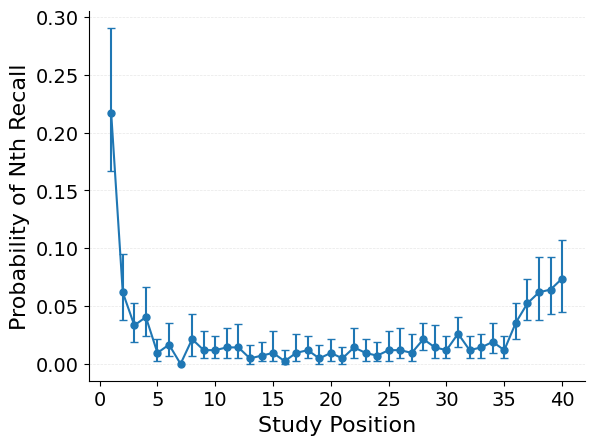

In [3]:
# parameters
run_tag = "PFR"
data_name = "LohnasKahana2014"
data_query = "data['list_type'] == 1"
data_path = os.path.join(find_project_root(), "data/LohnasKahana2014.h5")

# set up data structures
data = load_data(data_path)
recalls = data["recalls"]
presentations = data["pres_itemnos"]
list_length = data["listLength"][0].item()
trial_mask = generate_trial_mask(data, data_query)

# plot SPC
plot_pnr(data, generate_trial_mask(data, data_query))
